# Step1: Import librairies

In [2]:
#Data Manipulation
import pandas as pd
import numpy as np

#Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#Machine Learning Model
from sklearn.tree import DecisionTreeClassifier

#Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Step2: Upload and load dataset

In [4]:
from google.colab import files
df = pd.read_csv("/content/AI200_Module2 Lead_Conversion_Dataset.csv")

print(df.head())
print(df.shape)

   Age  Income  Website_Visits  Calls Previous_Purchase Converted
0   59   88182               6      1                No        No
1   49   32801               8      3               Yes       Yes
2   35  127881               6      5               Yes       Yes
3   63  109431               7      1                No        No
4   28   69749               9      2               Yes        No
(10000, 6)


# Step3: Explore dataset

In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Ddistribution:")
print(df['Converted'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                10000 non-null  int64 
 1   Income             10000 non-null  int64 
 2   Website_Visits     10000 non-null  int64 
 3   Calls              10000 non-null  int64 
 4   Previous_Purchase  10000 non-null  object
 5   Converted          10000 non-null  object
dtypes: int64(4), object(2)
memory usage: 468.9+ KB
None

Missing Values:
Age                  0
Income               0
Website_Visits       0
Calls                0
Previous_Purchase    0
Converted            0
dtype: int64

Class Ddistribution:
Converted
No     5519
Yes    4481
Name: count, dtype: int64




*   The dataset is clean with no missing values nor duplicates.
*   The datatype are correctly represented.
# Step4: Encode the categorical variables
Encoding into: Yes = 1 and No = 0




In [6]:
encoder = LabelEncoder()

df['Previous_Purchase'] = encoder.fit_transform(df['Previous_Purchase'])
df['Converted'] = encoder.fit_transform(df['Converted'])

df.head()

,Age,Income,Website_Visits,Calls,Previous_Purchase,Converted
0,59,88182,6,1,0,0
1,49,32801,8,3,1,1
2,35,127881,6,5,1,1
3,63,109431,7,1,0,0
4,28,69749,9,2,1,0


# Step5:

In [7]:
X = df.drop('Converted', axis=1)
y = df['Converted']

print(X.head())

   Age  Income  Website_Visits  Calls  Previous_Purchase
0   59   88182               6      1                  0
1   49   32801               8      3                  1
2   35  127881               6      5                  1
3   63  109431               7      1                  0
4   28   69749               9      2                  1


# step6: Split data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 8000
Testing Records: 2000


# Step7: Train the Decision tree model

In [9]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth = 5,
    random_state=42
)
dt_model.fit(X_train, y_train)
print("Model Training Complete")

Model Training Complete


# Step8: Make Predictions

In [10]:
y_pred = dt_model.predict(X_test)


# Step9: Evaluating the model

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))
print("precision:", round(precision,4))
print("recall:", round(recall,4))
print("F1 score:", round(f1,4))


Accuracy: 0.6315
precision: 0.5921
recall: 0.5703
F1 score: 0.581


# Step10: confusion Matrix

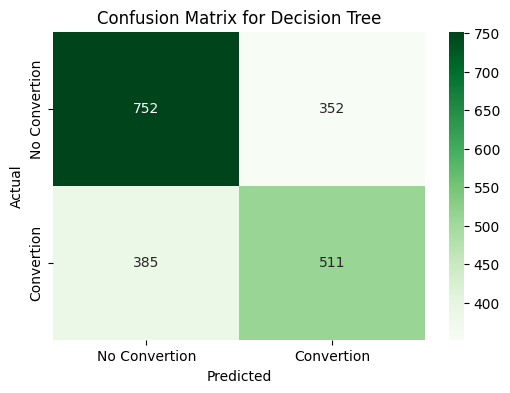

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Convertion','Convertion'],
    yticklabels=['No Convertion','Convertion']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Decision Tree")
plt.show()


# Step11: Classification report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.68      0.67      1104
           1       0.59      0.57      0.58       896

    accuracy                           0.63      2000
   macro avg       0.63      0.63      0.63      2000
weighted avg       0.63      0.63      0.63      2000



# Business Interpretation

The Decision Tree model predicts whether a lead is likely to convert into a customer based on the following factors:

Age, Income, Website Visits, Number of Calls and Previous Purchase History

This helps businesses identify potential customers and focus marketing and sales efforts on leads that are more likely to convert.

# Model Performance Interpretation

*   Accuracy (63.15%)

The model correctly classifies approximately 63% of all customers as either converting or not converting.

Precision: 59.21%


* Pre
   List item



When the model predicts that a customer will convert, it is correct about 59% of the time.

Business implication: Around 41% of customers predicted to convert may not actually convert, potentially leading to wasted marketing or sales resources.

Recall: 57.03%

The model successfully identifies approximately 57% of customers who actually convert.

Business implication: The model misses about 43% of potential converting customers, meaning some sales opportunities could be overlooked.

F1-Score: 58.01%

The F1-score represents the balance between Precision and Recall.

Business implication: A score of 58.01% indicates moderate performance. The model has a reasonable balance between identifying converters and avoiding false predictions, but there is room for improvement.

# Feature Importance

             Feature  Importance
4  Previous_Purchase    0.630313
1             Income    0.187133
3              Calls    0.064869
2     Website_Visits    0.059293
0                Age    0.058393


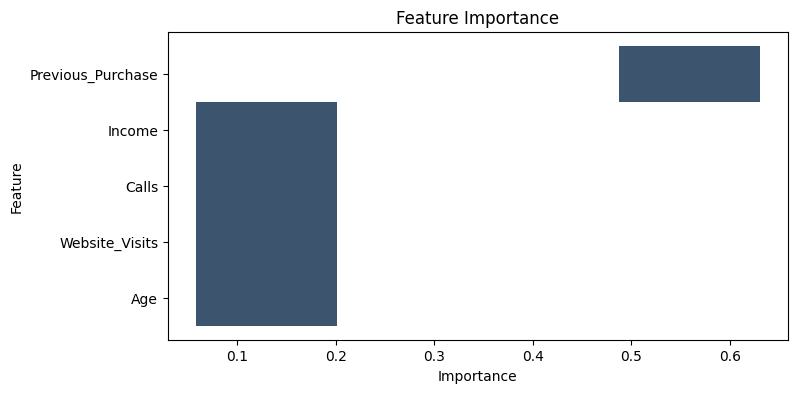

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

plt.figure(figsize=(8,4))
sns.histplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance")
plt.show()

# Deployment Recommendation
The current Decision Tree model demonstrates moderate predictive performance, with an accuracy of 63.15% and an F1-score of 58.01%. While it provides useful insights for lead prioritization, the model is not sufficiently accurate for fully automated decision-making. Additional feature engineering, model tuning, and testing of ensemble methods such as Random Forests are recommended before production deployment. The model may be used as a decision-support tool during further development and validation.